Student Marks Prediction Using the Dataset

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
data = pd.read_csv("/Users/barlamanivithreddy/Documents/Student_Marks_Prediction/student_exam_scores.csv")
print(data.head())

  student_id  hours_studied  sleep_hours  attendance_percent  previous_scores  \
0       S001            8.0          8.8                72.1               45   
1       S002            1.3          8.6                60.7               55   
2       S003            4.0          8.2                73.7               86   
3       S004            3.5          4.8                95.1               66   
4       S005            9.1          6.4                89.8               71   

   exam_score  
0        30.2  
1        25.0  
2        35.8  
3        34.0  
4        40.3  


In [3]:
print("\nData Info:")
print(data.info())
print("\nData Information:")
print(data.describe())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB
None

Data Information:
       hours_studied  sleep_hours  attendance_percent  previous_scores  \
count     200.000000   200.000000          200.000000       200.000000   
mean        6.325500     6.622000           74.830000        66.800000   
std         3.227317     1.497138           14.249905        15.663869   
min         1.000000     4.000000           50.300000        40.000000   
25%         3.500000     5.300000   

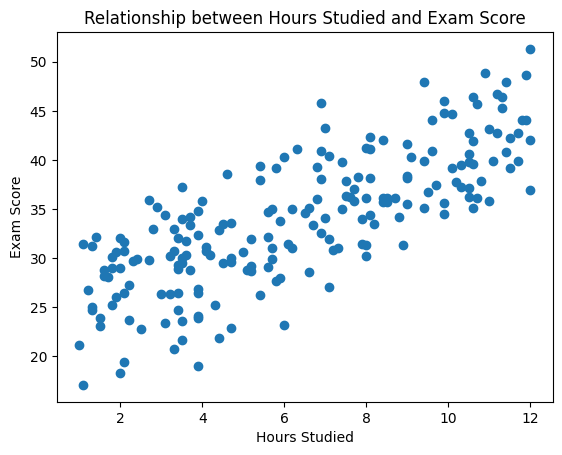

                    hours_studied  sleep_hours  attendance_percent  \
hours_studied            1.000000     0.077864           -0.031311   
sleep_hours              0.077864     1.000000            0.000572   
attendance_percent      -0.031311     0.000572            1.000000   
previous_scores          0.069078    -0.194251            0.051958   
exam_score               0.776751     0.188222            0.225713   

                    previous_scores  exam_score  
hours_studied              0.069078    0.776751  
sleep_hours               -0.194251    0.188222  
attendance_percent         0.051958    0.225713  
previous_scores            1.000000    0.431105  
exam_score                 0.431105    1.000000  


In [4]:
# Data Visualization
import matplotlib.pyplot as plt
plt.scatter(data['hours_studied'],data['exam_score'])
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Relationship between Hours Studied and Exam Score')
plt.show()
print(data.corr(numeric_only=True))

In [5]:
X = data[
    [
        'hours_studied',
        'sleep_hours',
        'attendance_percent',
        'previous_scores'
    ]
] 
y = data['exam_score']
print(X.head())
print(y.head())
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

   hours_studied  sleep_hours  attendance_percent  previous_scores
0            8.0          8.8                72.1               45
1            1.3          8.6                60.7               55
2            4.0          8.2                73.7               86
3            3.5          4.8                95.1               66
4            9.1          6.4                89.8               71
0    30.2
1    25.0
2    35.8
3    34.0
4    40.3
Name: exam_score, dtype: float64
(160, 4)
(40, 4)


In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Trained Successfully!")

Model Trained Successfully!


In [7]:
predictions = model.predict(X_test)
print(predictions[:10])
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})
print(results.head(10))

[28.88607164 29.68042066 35.31195586 31.18044826 39.44894287 41.69158322
 23.96918347 45.72250896 41.6529321  27.47615681]
     Actual  Predicted
95     28.7  28.886072
15     34.1  29.680421
30     34.5  35.311956
158    29.5  31.180448
128    36.1  39.448943
115    46.4  41.691583
69     23.9  23.969183
170    45.3  45.722509
174    44.8  41.652932
45     31.8  27.476157


In [8]:
from sklearn.metrics import r2_score
score = r2_score(y_test, predictions)
print("R² Score:", score)

R² Score: 0.8537447137159517


In [9]:
# Prediction
new_student = [[8, 7, 85, 80]]
prediction = model.predict(new_student)
print("Predicted Exam Score:", prediction[0])

Predicted Exam Score: 40.28224929748204


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
